<a href="https://colab.research.google.com/github/Thanvithmk/deep-learning/blob/main/DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [66]:
pip install tensorflow

In [67]:
import tensorflow as tf

In [68]:
print(tf.__version__)

2.20.0


In [69]:
#basic libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [70]:
df=pd.read_csv("/content/customer_churn_dataset-training-master.csv")
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [71]:
#Divide the dataset into independent and dependent sets
x=df.iloc[:5000,:-1]
y=df.iloc[:5000,-1]

In [72]:
x

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0
...,...,...,...,...,...,...,...,...,...,...,...
4995,5004.0,64.0,Female,21.0,27.0,1.0,5.0,Basic,Quarterly,157.0,10.0
4996,5005.0,28.0,Female,23.0,15.0,8.0,26.0,Basic,Annual,918.0,13.0
4997,5006.0,49.0,Male,60.0,1.0,9.0,24.0,Standard,Annual,471.0,21.0
4998,5007.0,31.0,Female,24.0,19.0,10.0,12.0,Basic,Annual,947.0,22.0


In [73]:
#Dummy Encoding (drop_first=True) - removes extra col
subs=pd.get_dummies(x["Subscription Type"],drop_first=True)
quat=pd.get_dummies(x["Contract Length"],drop_first=True)
gender=pd.get_dummies(x["Gender"],drop_first=True)

In [74]:
x = x.drop(["Gender","Subscription Type","Contract Length"],axis=1)

In [75]:
x

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction
0,2.0,30.0,39.0,14.0,5.0,18.0,932.0,17.0
1,3.0,65.0,49.0,1.0,10.0,8.0,557.0,6.0
2,4.0,55.0,14.0,4.0,6.0,18.0,185.0,3.0
3,5.0,58.0,38.0,21.0,7.0,7.0,396.0,29.0
4,6.0,23.0,32.0,20.0,5.0,8.0,617.0,20.0
...,...,...,...,...,...,...,...,...
4995,5004.0,64.0,21.0,27.0,1.0,5.0,157.0,10.0
4996,5005.0,28.0,23.0,15.0,8.0,26.0,918.0,13.0
4997,5006.0,49.0,60.0,1.0,9.0,24.0,471.0,21.0
4998,5007.0,31.0,24.0,19.0,10.0,12.0,947.0,22.0


In [76]:
x=pd.concat([x,gender,subs,quat],axis=1)

In [77]:
x

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Male,Premium,Standard,Monthly,Quarterly
0,2.0,30.0,39.0,14.0,5.0,18.0,932.0,17.0,False,False,True,False,False
1,3.0,65.0,49.0,1.0,10.0,8.0,557.0,6.0,False,False,False,True,False
2,4.0,55.0,14.0,4.0,6.0,18.0,185.0,3.0,False,False,False,False,True
3,5.0,58.0,38.0,21.0,7.0,7.0,396.0,29.0,True,False,True,True,False
4,6.0,23.0,32.0,20.0,5.0,8.0,617.0,20.0,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,5004.0,64.0,21.0,27.0,1.0,5.0,157.0,10.0,False,False,False,False,True
4996,5005.0,28.0,23.0,15.0,8.0,26.0,918.0,13.0,False,False,False,False,False
4997,5006.0,49.0,60.0,1.0,9.0,24.0,471.0,21.0,True,False,True,False,False
4998,5007.0,31.0,24.0,19.0,10.0,12.0,947.0,22.0,False,False,False,False,False


In [78]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [79]:
#feature scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [80]:
x_train

array([[ 0.28899636,  1.63018677,  1.67112567, ...,  1.42247376,
        -0.70419196,  1.40341084],
       [ 0.54017431, -1.22393781,  0.87135951, ..., -0.70300067,
         1.42006734, -0.71254972],
       [-1.19448002,  0.84530251,  1.21411643, ..., -0.70300067,
        -0.70419196, -0.71254972],
       ...,
       [-0.58526942, -1.08123158,  1.27124259, ..., -0.70300067,
         1.42006734, -0.71254972],
       [ 0.07667467,  0.20312448, -0.95667742, ..., -0.70300067,
        -0.70419196, -0.71254972],
       [ 0.16340739, -1.36664404,  0.87135951, ..., -0.70300067,
        -0.70419196,  1.40341084]])

In [81]:
#ANN

In [82]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
#from tensorflow.keras.layers import LeakyRelu

In [83]:
classifier=Sequential()

In [84]:
classifier.add(Dense(units=11,activation="relu"))

In [85]:
classifier.add(Dense(units=7,activation="relu"))

In [86]:
classifier.add(Dense(units=6,activation="relu"))

In [87]:
classifier.add(Dense(units=1,activation="sigmoid"))

In [88]:
classifier.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [89]:
#early stopping
import tensorflow as tf
early_stop=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0,
    patience=0,
    verbose=0,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)


In [90]:
hist=classifier.fit(x_train,y_train,validation_split=0.33,batch_size=10,epochs=100,callbacks=early_stop)

Epoch 1/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9205 - loss: 0.3492 - val_accuracy: 0.9553 - val_loss: 0.1906
Epoch 2/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9589 - loss: 0.1605 - val_accuracy: 0.9553 - val_loss: 0.1425
Epoch 3/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9589 - loss: 0.1281 - val_accuracy: 0.9553 - val_loss: 0.1205
Epoch 4/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9589 - loss: 0.1104 - val_accuracy: 0.9553 - val_loss: 0.1080
Epoch 5/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9589 - loss: 0.0997 - val_accuracy: 0.9553 - val_loss: 0.1007
Epoch 6/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9589 - loss: 0.0933 - val_accuracy: 0.9553 - val_loss: 0.0943
Epoch 7/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9589 - loss: 0.0879 - val_accuracy: 0.9553 - val_loss: 0.0884
Epoch 8/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9589 - loss: 0.0833 - val

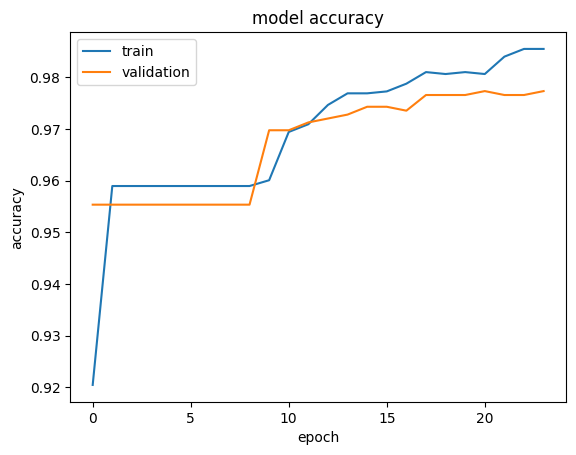

In [91]:
plt.plot(hist.history["accuracy"])
plt.plot(hist.history["val_accuracy"])
plt.title("model accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(["train","validation"],loc="upper left")
plt.show()

In [92]:
y_pred=classifier.predict(x_test)
y_pred=(y_pred>0.5)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
